### Analisis y procesamiento de señales - UNSAM <img src=./logo_UNSAM.jpg align = right width = 150>
## TS1: Síntesis y operaciones de señales
### Jeronimo Lanzavechia

# Ejercicio 1 

### Utilizando siempre N = 1000 muestras. Se pide:

### Sintetizar:

   - Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.
   - Misma señal con 2 W de potencia media y desfasada en π/2.
   - Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.
   - Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 
   - Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50% (Ver scipy.signal apartado Waveforms).

Para cada señal visualice el módulo de la transformada de Fourier.

### Bonus:
   - 🤯Implementar alguna otra señal disponible en scipy.signal.
   - 💎Averiguar cómo se podría medir la potencia mediante la transformada de Fourier (Ver Teorema de Parseval)


Disclaimer: El formateo de los gráficos como subplots se hizo con asistencia de chat-gpt. 

Para hacer mejor la lectura del TS1 y hacer mas sencilla la reutilizacion de las funciones, se hizo una libreria que contiene las funciones hechas en clase y para este mismo trabajo.
En este TS, se utilizaron las siguientes:

In [12]:
import numpy as np
import scipy.signal as ss
import scipy.fft as scfft

def mi_funcion_seno(vmax, dc, ff, ph, nn, fs):
    """
    Variables de entrada
    vmax = Amplitud
    dc = componente de continua
    ff = frecuencia de señal
    ph = desplazamiento de fase
    nn = numero de muestras
    fs = frecuencia de muestreo
    Salida
    dt, amplitud a dt 
    """
    
    tt =  np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx

#hecha para TS1
def mi_ruido(A,dist,dc,n,fs):
    """
    P = potencia o varianza que maneja la distribucion del ruido sin dc
    dc = componente de continua
    dist = distribucion (normal, uniform)
    n = numero de muestras
    """
    potencia = (A**2)/2
    noise = []
    if dist == "normal":    
        for i in range(n):
            noise.append(np.random.normal(0,np.sqrt(potencia)) + dc)
    elif dist == "uniform":
        for i in range(n):
            noise.append(np.random.uniform(-A,A) + dc)
            #La potencia media de una distribucion uniforme es (vmax - vmin)²/12
            #despejando, siendo que vmax = -vmin, queda que P = 4vmax²/12
            #simplificando, P = vmax²/3
            #la vmax me da una amplitud, siendo que la distribucion la centro en dc,
            #entonces vmax = A = sqrt(P*3)
    else:
        print("Distribucion no disponible")
        return noise
    
    tt =  np.arange(start = 0, stop = n/fs, step = 1/fs)
    return tt, noise
    
#hecha para TS1
def mi_cuadrada(A,duty,dc,ff,n,fs):
    tt =  np.arange(start = 0, stop = n/fs, step = 1/fs)
    xx = A * ss.waveforms.square(2*np.pi*ff*tt,duty) + dc
    return tt,xx

#hecha en clase
def spectometer (signal,n,fs):
    ww = np.arange(start = 0, stop = fs/2, step = fs/n)
    #transformo la señal
    trafo_signal_N = scfft.fft(signal,n)
    trafo_signal = 1/n * trafo_signal_N[:n//2]
    #doy modulo y fase
    modulo_trafo_signal = np.abs(trafo_signal)
    fase_trafo_signal = np.angle(trafo_signal)
    modulo_db = 20 * np.log10(2*modulo_trafo_signal)
    return ww,modulo_db,fase_trafo_signal

# Sintetizado
Siendo que tenemos 20000Hz de fs, se muestra el espectro hasta la mitad de esa frecuencia.

Se reutilizó la función "mi_funcion_seno" del TS0 para este TS. Se llama la función desde mi_libreria (as lib) y se le pasan los parametros para generar la señal pedida. Lo mismo para el punto 2.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as ss
import mi_libreria as lib #mi libreria con funciones hechas durante la cursada

N = 1000 #numero de muestras

1 - Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período, con su espectro.

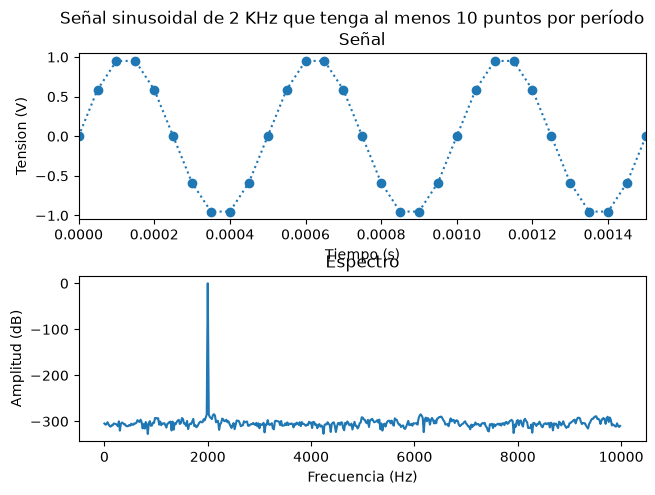

In [14]:
#10 puntos por periodo = 2khz*10 = fs = 20000
fs = 20000
t1,x1 = lib.mi_funcion_seno(vmax = 1,dc = 0, ff = 2000,ph = 0,nn = N,fs = fs)
#transformada
ww,modulo_tf1,fase_tf1 = lib.spectometer(x1, N, fs)

fig, (fdt,fdf) = plt.subplots(2,1)
fig.suptitle("Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período")
fig.tight_layout(h_pad = 2)
#subplot de la funcion en el tiempo
fdt.set_title("Señal")
fdt.set_xlabel("Tiempo (s)")
fdt.set_ylabel("Tension (V)")
fdt.set_xlim(0,3*1/2000)
fdt.plot(t1,x1,':o')
#fdt.xlim(0, 3*1/2000) #muestro 3 ciclos de la seno
#subplot en la frecuencia
fdf.set_title("Espectro")
fdf.set_xlabel("Frecuencia (Hz)")
fdf.set_ylabel("Amplitud (dB)")
fdf.plot(ww,modulo_tf1)

2 - Misma señal con 2 W de potencia media y desfasada en π/2, con su espectro.

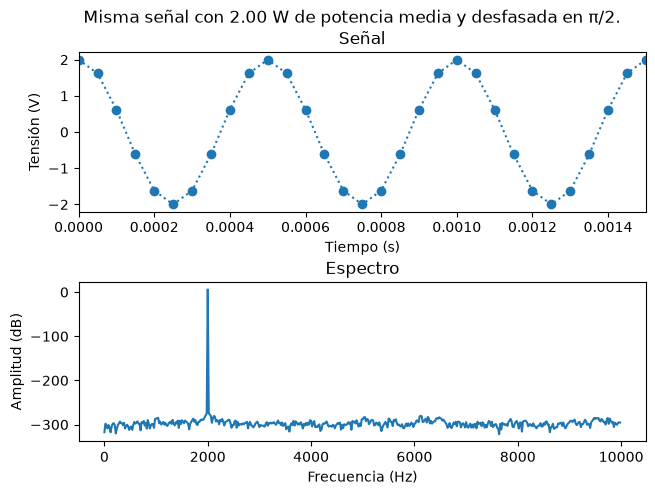

In [15]:
fs = 20000
t2,x2 = lib.mi_funcion_seno(vmax = 2,dc = 0, ff = 2000,ph = np.pi/2,nn = N,fs = fs)
potencia_media = (1/N)*np.sum(np.square(x2)) # demuestro que tiene 2W de potencia media
#no implemente la funcion con la potencia, sino con la amplitud/tension maxima
#transformada
ww2,modulo_tf2,fase_tf2 = lib.spectometer(x2, N,fs)

fig2, (fdt2,fdf2) = plt.subplots(2,1)
fig2.suptitle(f"Misma señal con {potencia_media:.2f} W de potencia media y desfasada en π/2.")
fig2.tight_layout(h_pad = 3)
#f me permite mostrar el valor de variables en strings, como si fueran parte del string
#con .2f reduzco el tamaño del float a 2 decimales
#subplot de la funcion en el tiempo
fdt2.set_title("Señal")
fdt2.set_xlabel("Tiempo (s)")
fdt2.set_ylabel("Tensión (V)")
fdt2.set_xlim(0,3*1/2000)
fdt2.plot(t2,x2,':o')
#fdt.xlim(0, 3*1/2000) #muestro 3 ciclos de la seno
#subplot en la frecuencia
fdf2.set_title("Espectro")
fdf2.set_xlabel("Frecuencia (Hz)")
fdf2.set_ylabel("Amplitud (dB)")
fdf2.plot(ww2,modulo_tf2)

Para ambas señales de ruido, se implemento la señal mi_ruido, que recibe, entre otros argumentos, la distribucion del ruido que se quiere generar, y devuelve dicha distribucion para la secuencia. El resto de argumentos son:
3 - Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.

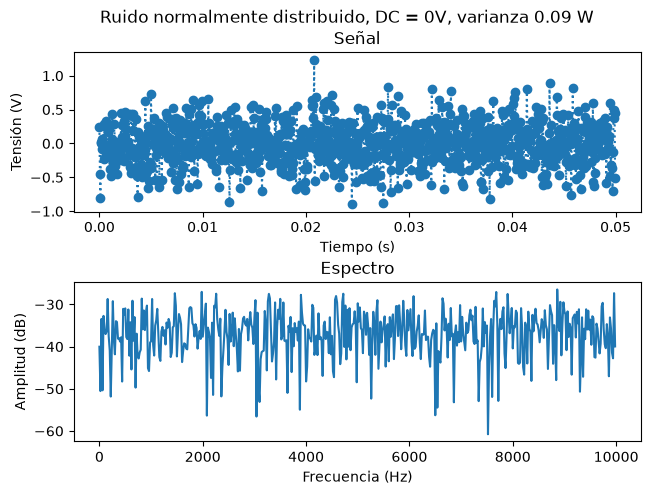

In [16]:
fs = 20000
t3,x3 = lib.mi_ruido(A = np.sqrt(2 * 0.1) , dist = "normal" , dc = 0 , n = N ,fs = fs)
potencia_ruido = (1/N)*np.sum(np.square(x3)) #demuestro que tiene 0.1W de potencia media
ww3,modulo_tf3,fase_tf3 = lib.spectometer(x3, N,fs)

fig3, (fdt3,fdf3) = plt.subplots(2,1)
fig3.suptitle(f"Ruido normalmente distribuido, DC = 0V, varianza {potencia_ruido:0.2f} W")
fig3.tight_layout(h_pad = 3)
#subplot de la funcion en el tiempo
fdt3.set_title("Señal")
fdt3.set_xlabel("Tiempo (s)")
fdt3.set_ylabel("Tensión (V)")
fdt3.plot(t3,x3,':o')
fdf3.set_title("Espectro")
fdf3.set_xlabel("Frecuencia (Hz)")
fdf3.set_ylabel("Amplitud (dB)")
fdf3.plot(ww3,modulo_tf3)

4 - Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 

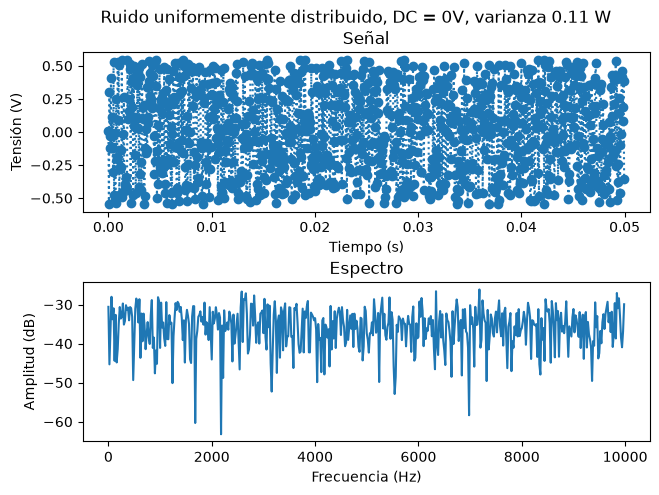

In [17]:
fs = 20000
t4,x4 = lib.mi_ruido(A = np.sqrt(3*0.1) , dist = "uniform" , dc = 0 , n = N ,fs = fs)
potencia_ruido = (1/N)*np.sum(np.square(x4)) #demuestro que tiene 0.1W de potencia media
ww4,modulo_tf4,fase_tf4 = lib.spectometer(x4, N,fs)

fig4, (fdt4,fdf4) = plt.subplots(2,1)
fig4.suptitle(f"Ruido uniformemente distribuido, DC = 0V, varianza {potencia_ruido:0.2f} W")
fig4.tight_layout(h_pad = 3)
#subplot de la funcion en el tiempo
fdt4.set_title("Señal")
fdt4.set_xlabel("Tiempo (s)")
fdt4.set_ylabel("Tensión (V)")
fdt4.plot(t4,x4,':o')
fdf4.set_title("Espectro")
fdf4.set_xlabel("Frecuencia (Hz)")
fdf4.set_ylabel("Amplitud (dB)")
fdf4.plot(ww4,modulo_tf4)

Se implementó una funcion propia para resolver este punto, pasandole como argumentos:
5 - Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50% (Ver scipy.signal apartado Waveforms).

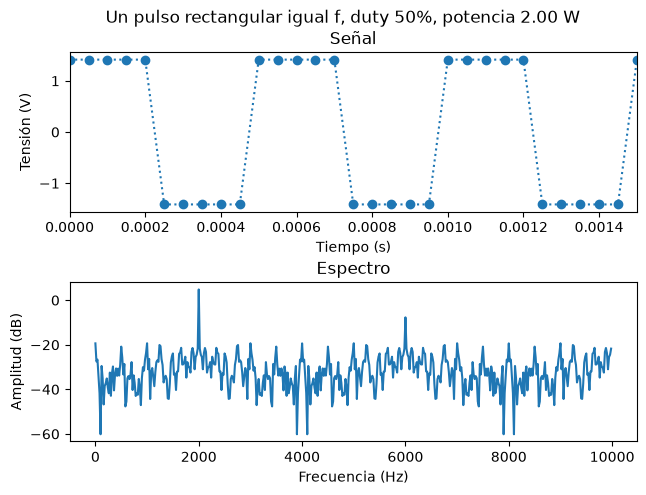

In [18]:
fs = 20000
ff = 2000
t5,x5 = lib.mi_cuadrada(A = np.sqrt(2) , duty= 0.5 , dc= 0, ff= 2000 , n = N ,fs = fs)
potencia_ruido = (1/N)*np.sum(np.square(x5)) #demuestro que tiene 1 de potencia media
ww5,modulo_tf5,fase_tf5 = lib.spectometer(x5, N,fs)

fig5, (fdt5,fdf5) = plt.subplots(2,1)
fig5.suptitle(f"Un pulso rectangular igual f, duty 50%, potencia {potencia_ruido:0.2f} W")
fig5.tight_layout(h_pad = 3)
#subplot de la funcion en el tiempo
fdt5.set_title("Señal")
fdt5.set_xlabel("Tiempo (s)")
fdt5.set_ylabel("Tensión (V)")
fdt5.set_xlim(0,3*1/2000)
fdt5.plot(t5,x5,':o')
fdf5.set_title("Espectro")
fdf5.set_xlabel("Frecuencia (Hz)")
fdf5.set_ylabel("Amplitud (dB)")
fdf5.plot(ww5,modulo_tf5)

## Bonus

1 - 🤯Implementar alguna otra señal disponible en scipy.signal.

Se implementó una señal que genera una delta de kronecker, pasandole como parametros la posicion de la delta en las muestras, la cantidad de muestras y la frecuencia de muestreo.

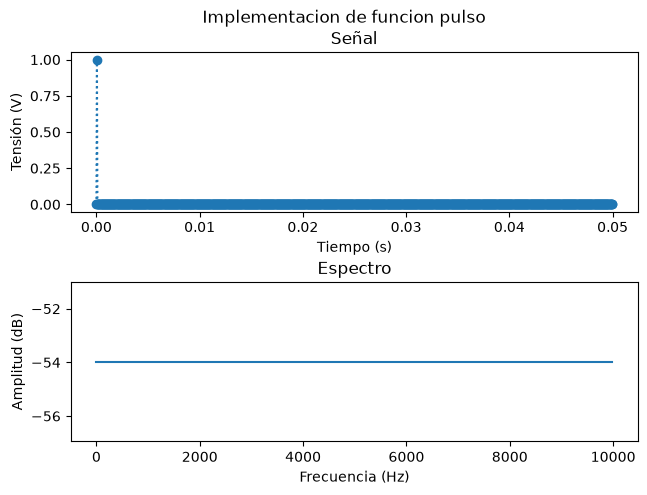

In [19]:
def mi_pulso(pos,n,fs):
    tt = np.arange(start = 0, stop = n/fs, step = 1/fs)
    pulso = ss.unit_impulse(64,pos)
    xx = []
    for i in range(n):
        if i < 64: xx.append(pulso[i])
        else: xx.append(0)
    return tt, xx

#pruebo el pulso
fs = 20000
ff = 2000
t6,x6 = mi_pulso(1, N, fs)
ww6,modulo_tf6,fase_tf6 = lib.spectometer(x6, N,fs)

fig6, (fdt6,fdf6) = plt.subplots(2,1)
fig6.suptitle("Implementacion de funcion pulso")
fig6.tight_layout(h_pad = 3)
#subplot de la funcion en el tiempo
fdt6.set_title("Señal")
fdt6.set_xlabel("Tiempo (s)")
fdt6.set_ylabel("Tensión (V)")
fdt6.plot(t6,x6,':o')
fdf6.set_title("Espectro")
fdf6.set_xlabel("Frecuencia (Hz)")
fdf6.set_ylabel("Amplitud (dB)")
fdf6.plot(ww6,modulo_tf6)

2 - 💎Averiguar cómo se podría medir la potencia mediante la transformada de Fourier (Ver Teorema de Parseval)
El Teorema de Parseval dice que la suma del cuadrado de las componentes de la transformada de una funcion es igual a su energía.

Si al resultado de una DFT, se aplica el teorema de parseval discreto, se obtiene el valor de la energia de la señal. Normalizada a 1 ohm, se obtiene la potencia de la señal. Hay que volver a dividir por N para obtener la potencia, ya que se hace la sumatoria de las componentes. 

In [20]:
import scipy.fft as scfft
t,x = lib.mi_funcion_seno(np.sqrt(2),0,2000,0,N,fs)
potencia = (1/N**2)*np.sum(np.abs(scfft.fft(x,N))**2)
print(potencia)

1.0000000000000007
